<a href="https://colab.research.google.com/github/AditiSinghal28/Machine-Learning-Projects/blob/main/DL_project_5_Face_Mask_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [3]:
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')


In [4]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:01<00:00, 126MB/s]



In [5]:
#extracting the compressed dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [6]:
!ls

data  face-mask-dataset.zip  sample_data


IMPORTING THE DEPENDENCIES

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [8]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])

['with_mask_1638.jpg', 'with_mask_3168.jpg', 'with_mask_3652.jpg', 'with_mask_2523.jpg', 'with_mask_3439.jpg']


In [10]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])

['without_mask_2503.jpg', 'without_mask_634.jpg', 'without_mask_1385.jpg', 'without_mask_2921.jpg', 'without_mask_3408.jpg']


In [11]:
print('Number of with mask images : ', len(with_mask_files))
print('Number of without mask images : ', len(without_mask_files))

Number of with mask images :  3725
Number of without mask images :  3828


Creating labels for two image classes

without mask -> 0

with mask -> 1


In [12]:
#creating labels

with_mask_labels = [1]*3725
without_mask_labels = [0]*3828 ##len of without mask files

In [14]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [15]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [16]:
labels = with_mask_labels + without_mask_labels

In [17]:
print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the images**

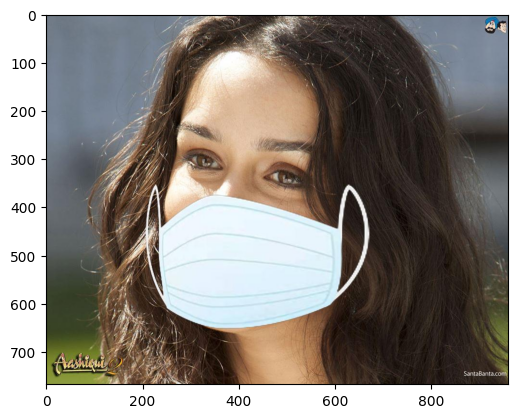

In [18]:
#display with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1638.jpg')
imgplot = plt.imshow(img)
plt.show()

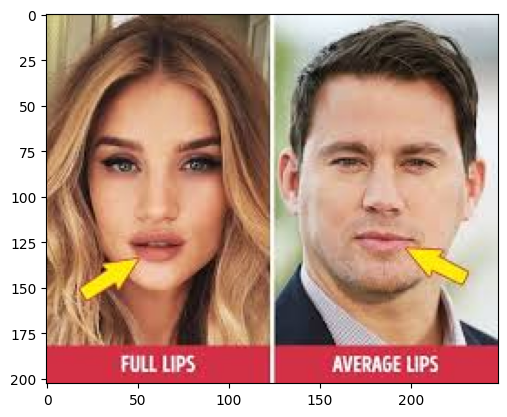

In [19]:
#display without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2503.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**



1.   Resize the images
2.   Convert images to numpy arrays



In [20]:
# convert images to numpy arrays

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:
  image = Image.open(with_mask_path + img_file)
  image = image.resize((128, 128))
  image = image.convert('RGB')
  image = np.array(image)

  data.append(image)


without_mask_path = '/content/data/without_mask/'

for img_file in without_mask_files:
  image = Image.open(without_mask_path + img_file)
  image = image.resize((128, 128))
  image = image.convert('RGB')
  image = np.array(image)

  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [21]:
len(data)

7553

In [22]:
type(data)

list

In [23]:
data[0:5]

[array([[[111, 121, 133],
         [112, 122, 134],
         [111, 121, 133],
         ...,
         [118, 127, 140],
         [114, 125, 140],
         [114, 126, 140]],
 
        [[112, 122, 134],
         [113, 123, 135],
         [112, 122, 134],
         ...,
         [105, 131, 148],
         [119, 132, 146],
         [116, 130, 144]],
 
        [[112, 122, 134],
         [113, 123, 135],
         [112, 122, 134],
         ...,
         [ 53, 103, 136],
         [ 69,  69,  79],
         [ 98, 102, 116]],
 
        ...,
 
        [[136, 150,  59],
         [137, 152,  57],
         [113, 127,  47],
         ...,
         [ 71,  61,  52],
         [ 78,  66,  56],
         [102,  92,  62]],
 
        [[139, 154,  61],
         [138, 153,  61],
         [141, 156,  61],
         ...,
         [ 53,  42,  32],
         [ 62,  48,  38],
         [ 77,  65,  42]],
 
        [[140, 155,  62],
         [140, 155,  62],
         [140, 155,  64],
         ...,
         [ 48,  38,  27],
  

array([[[222, 195, 183],
        [200, 165, 153],
        [203, 168, 156],
        ...,
        [204, 170, 156],
        [204, 170, 156],
        [204, 170, 157]],

       [[202, 164, 153],
        [170, 133, 121],
        [173, 136, 124],
        ...,
        [175, 137, 124],
        [176, 137, 124],
        [176, 137, 125]],

       [[210, 168, 156],
        [178, 136, 125],
        [181, 139, 127],
        ...,
        [182, 140, 129],
        [182, 140, 129],
        [182, 140, 130]],

       ...,

       [[208, 206, 217],
        [187, 185, 196],
        [195, 193, 204],
        ...,
        [153, 153, 162],
        [230, 223, 226],
        [229, 216, 215]],

       [[207, 205, 216],
        [190, 188, 199],
        [196, 194, 205],
        ...,
        [137, 138, 148],
        [222, 216, 220],
        [231, 219, 219]],

       [[224, 222, 233],
        [210, 208, 219],
        [215, 213, 224],
        ...,
        [171, 172, 180],
        [231, 226, 229],
        [236, 225, 225]]], dtype=uint8)
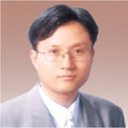

In [24]:
data[-1]

In [25]:
type(data[-1])

numpy.ndarray

In [26]:
data[0].shape

(128, 128, 3)

In [27]:
#converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [28]:
type(X)

numpy.ndarray

In [29]:
type(Y)

numpy.ndarray

In [30]:
X.shape

(7553, 128, 128, 3)

In [31]:
Y.shape

(7553,)

Train test Split

In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [33]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [34]:
## scaling the data

X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [35]:
X_train_scaled[0]

array([[[0.74509804, 0.74509804, 0.74509804],
        [0.74117647, 0.74117647, 0.74117647],
        [0.7254902 , 0.7254902 , 0.7254902 ],
        ...,
        [0.46666667, 0.46666667, 0.46666667],
        [0.4745098 , 0.4745098 , 0.4745098 ],
        [0.48235294, 0.48235294, 0.48235294]],

       [[0.66666667, 0.66666667, 0.66666667],
        [0.69803922, 0.69803922, 0.69803922],
        [0.74901961, 0.74901961, 0.74901961],
        ...,
        [0.45882353, 0.45882353, 0.45882353],
        [0.4745098 , 0.4745098 , 0.4745098 ],
        [0.49411765, 0.49411765, 0.49411765]],

       [[0.84705882, 0.84705882, 0.84705882],
        [0.8627451 , 0.8627451 , 0.8627451 ],
        [0.88235294, 0.88235294, 0.88235294],
        ...,
        [0.44705882, 0.44705882, 0.44705882],
        [0.4745098 , 0.4745098 , 0.4745098 ],
        [0.49411765, 0.49411765, 0.49411765]],

       ...,

       [[0.96862745, 0.97254902, 0.96862745],
        [0.55294118, 0.50980392, 0.48627451],
        [0.27058824, 0

**Building a Convolutional Neural Network**

In [36]:
import tensorflow as tf
from tensorflow import keras

In [37]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape = (128, 128, 3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
#compiling the neural network
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['acc'])

In [39]:
#training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs = 5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - acc: 0.8017 - loss: 0.4555 - val_acc: 0.8926 - val_loss: 0.2721
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.8884 - loss: 0.2849 - val_acc: 0.9107 - val_loss: 0.2116
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.9126 - loss: 0.2356 - val_acc: 0.9256 - val_loss: 0.1975
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9290 - loss: 0.1833 - val_acc: 0.9421 - val_loss: 0.1744
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9378 - loss: 0.1579 - val_acc: 0.9455 - val_loss: 0.1541


**Model Evaluation**

In [40]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test accuracy : ', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9265 - loss: 0.2119
Test accuracy :  0.9265387058258057


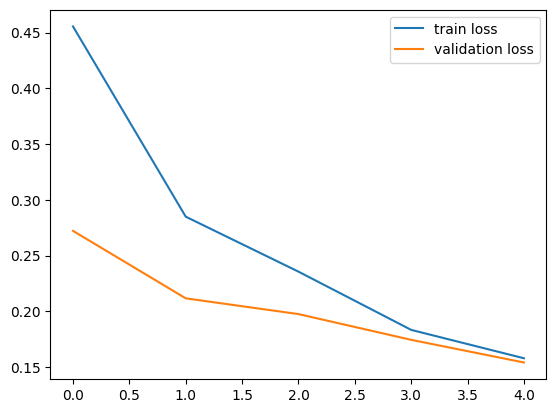

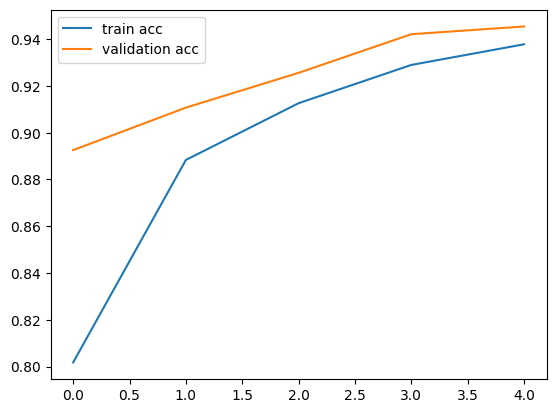

In [42]:
h = history
#plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

#plot the accuracy value
plt.plot(h.history['acc'], label='train acc')
plt.plot(h.history['val_acc'], label='validation acc')
plt.legend()
plt.show()

**Predictive System**

Path of the image to be predicted : /content/young-man-wearing-black-face-260nw-1696092880.webp


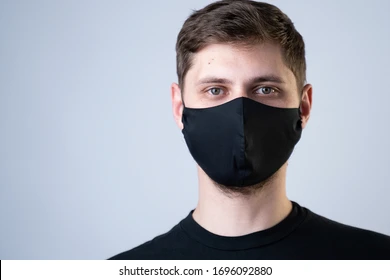

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[[0.11064377 0.94778156]]
The person in the image is wearing mask


In [45]:
input_image_path = input('Path of the image to be predicted : ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128, 128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1, 128, 128, 3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

if input_pred_label == 1:
  print('The person in the image is wearing mask')
else:
  print('The person in the image is not wearing mask')